In [4]:
import pandas as pd 
import numpy as np
import cvxpy as cp
import math
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from conditionalconformal import CondConf
from conditionalconformal.condconf import setup_cvx_problem_calib

from prob_setup import setup_full_cvx_dual
import mosek

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def generateGaussData(nTrain,nTest,d,wZero=False):
    if d == 0:
        XTrain = np.ones(nTrain).reshape(-1,1)
        YTrain = np.random.normal(size=nTrain)
        XTest = np.ones(nTest).reshape(-1,1)
        YTest =  np.random.normal(size=nTest)
        return XTrain, YTrain, XTest, YTest
        
    XTrain = np.random.normal(size=(nTrain,d))
    XTest = np.random.normal(size=(nTest,d))
    
    if wZero:
        w = np.zeros(d)
    else:
        w = np.random.normal(size=d)
        w = w/math.sqrt(sum(w**2))
    
    YTrain = XTrain@w + np.random.normal(size=nTrain)
    YTest = XTest@w + np.random.normal(size=nTest)
    
    XTrain = np.column_stack((np.ones(nTrain),XTrain))
    XTest = np.column_stack((np.ones(nTest),XTest))

    return XTrain, YTrain, XTest, YTest


In [6]:
def oneFCExperiment(nTrain,nTest,d,alpha,wZero=False):
    ### Generate data
    XTrain, YTrain, XTest, YTest = generateGaussData(nTrain,nTest,d,wZero = wZero)
    
    ### Run our conditional calibration randomized and non-randomized
    scoreFn = lambda x, y : y if isinstance(y, np.ndarray) else np.array([y])
    phiFn = lambda x : x if isinstance(x, np.ndarray) else np.array([x])
    condCovProgram = CondConf(scoreFn, phiFn)
    condCovProgram.setup_problem(XTrain,YTrain)
    
    condCovsRandLength = 0
    condCovsRandCov = []
    for i in range(nTest):
        up = condCovProgram.predict(1-alpha/2, XTest[i,:].reshape(1,d+1),
                                                           lambda x, y : x, randomize=True, exact=True)[0]
        low = condCovProgram.predict(alpha/2, XTest[i,:].reshape(1,d+1),
                                                           lambda x, y : x, randomize=True, exact=True)[0]
        condCovsRandLength = condCovsRandLength + (up - low)/nTest
        condCovsRandCov.append(float(YTest[i] <= up and YTest[i] >=low))
    condCovsRandCov = np.array(condCovsRandCov)
    condCovsRandMeanCov = np.mean(condCovsRandCov)
    condCovsRandWorst = np.max(abs(XTest.T@(condCovsRandCov - (1-alpha)))/np.apply_along_axis(lambda x: np.sum(abs(x)),0,XTest))

    condCovsConsLength = 0
    condCovsConsCov = []
    for i in range(nTest):
        up = condCovProgram.predict(1-alpha/2, XTest[i,:].reshape(1,d+1),
                                                           lambda x, y : x, randomize=False, exact=True)[0]
        low = condCovProgram.predict(alpha/2, XTest[i,:].reshape(1,d+1),
                                                           lambda x, y : x, randomize=False, exact=True)[0]

        condCovsConsLength = condCovsConsLength + (up - low)/nTest
        condCovsConsCov.append(float(YTest[i] <= up and YTest[i] >=low))
    condCovsConsCov = np.array(condCovsConsCov)
    condCovsMeanCov = np.mean(condCovsConsCov)
    condCovsConsWorst = np.max(abs(XTest.T@(condCovsConsCov - (1-alpha)))/np.apply_along_axis(lambda x: np.sum(abs(x)),0,XTest))

    ### Run vanilla QR
    probU = setup_full_cvx_dual(XTrain, YTrain, None, None, 1-alpha/2, XTrain)
    probU.solve(
                solver='MOSEK', 
                verbose=False, 
                mosek_params={mosek.iparam.intpnt_solve_form: mosek.solveform.dual}
            )
    cUp = probU.constraints[-1].dual_value
    probL = setup_full_cvx_dual(XTrain, YTrain, None, None, alpha/2, XTrain)
    probL.solve(
                solver='MOSEK', 
                verbose=False, 
                mosek_params={mosek.iparam.intpnt_solve_form: mosek.solveform.dual}
            )
    cLow = probL.constraints[-1].dual_value

    lengthQR = np.mean(XTest@cUp - XTest@cLow)
    covQR = np.logical_and(YTest <= XTest@cUp, YTest >= XTest@cLow).astype(float)
    covQR = np.array(covQR)
    covQRMeanCov = np.mean(covQR)
    condCovQRWorst = np.max(abs(XTest.T@(covQR - (1-alpha)))/np.apply_along_axis(lambda x: np.sum(abs(x)),0,XTest))

    lengthData = pd.DataFrame({'Method': ['Conditional Calibration (Randomized)', 
                                            'Conditional Calibration (Unrandomized)', 'Quantile Regression'],
                                'Length': [condCovsRandLength,condCovsConsLength,lengthQR],
                               'Marginal Coverage':[condCovsRandMeanCov,condCovsMeanCov,covQRMeanCov],
                              'Worst Case Conditional Coverage' : [condCovsRandWorst,condCovsConsWorst,condCovQRWorst]})

    return lengthData



In [7]:
np.random.seed(11)

nTrials = 100
nTest = 1000
ds = [0, 20, 40, 60, 80]
nTrain = 400

alpha = 0.1

coverageDF = pd.DataFrame()
for d in (ds):
    for i in tqdm(range(nTrials)):
        appendDF = oneFCExperiment(nTrain,nTest,d,alpha,wZero=True)

        appendDF['trial'] = i
        appendDF['Calibration Set Size'] = nTrain
        appendDF['Function Class Dimension'] = d
        coverageDF = pd.concat([coverageDF,appendDF])   

100%|██████████████████████████████████████| 100/100 [5:19:35<00:00, 191.76s/it]


In [3]:
alpha = 0.1
ds = [0, 20, 40, 60, 80]
nTrials = 100

lengthDF = pd.DataFrame()
for d in ds:
    for i in tqdm(range(nTrials)):
        appendDF = oneFCExperiment(nTrain,nTest,d,alpha,wZero=False)

        appendDF['trial'] = i
        appendDF['Calibration Set Size'] = nTrain
        appendDF['Function Class Dimension'] = d
        lengthDF = pd.concat([lengthDF,appendDF])   

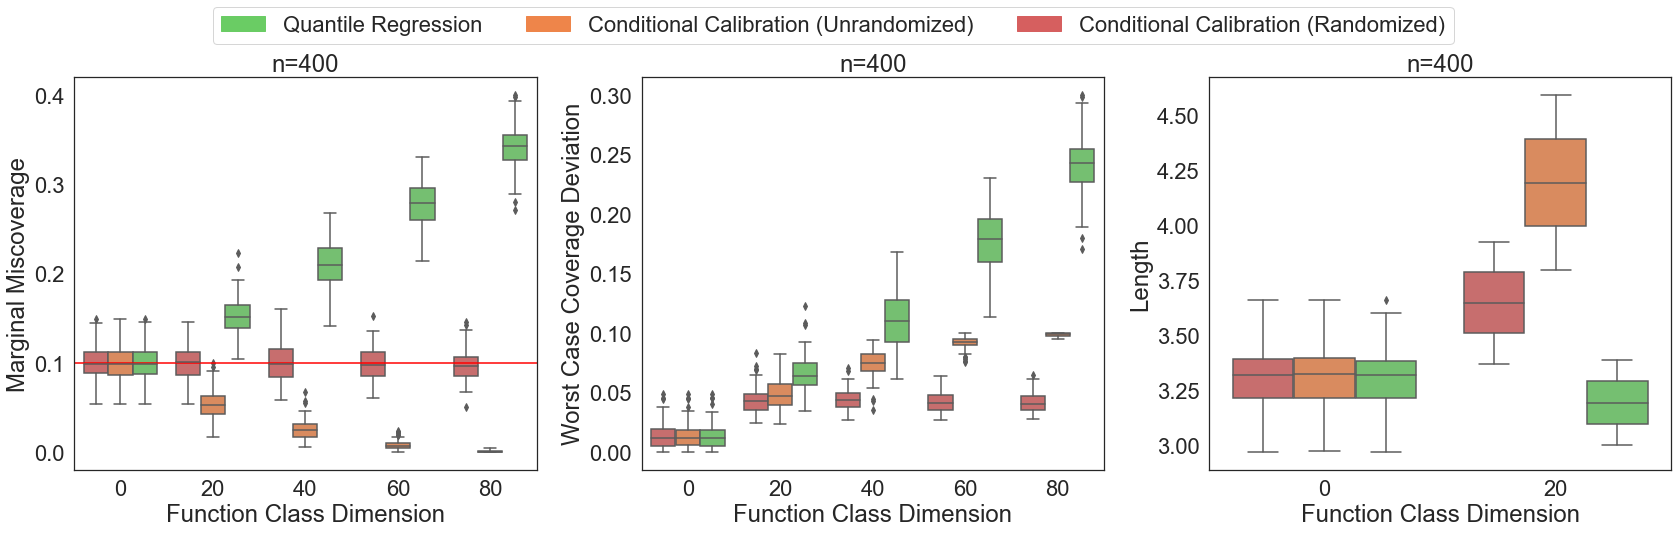

In [10]:
sns.set(rc={'figure.figsize':(24,7.3)})
sns.set(font_scale=2)
sns.set_style(style='white')
fig, axs = plt.subplots(1, 3, figsize=(24,7.3))

#coverageDF2.loc[coverageDF2.Method == 'Quantile Regression', 'Method'] = "Quantile Regression, Jung et al. (2023)"
#lengthDF2.loc[lengthDF2.Method == 'Quantile Regression', 'Method'] = "Quantile Regression, Jung et al. (2023)"

my_pal = {"Quantile Regression": sns.color_palette("muted")[:][2],
          "Conditional Calibration (Unrandomized)": sns.color_palette("muted")[:][1],
         "Conditional Calibration (Randomized)": sns.color_palette("muted")[:][3]}

#ax1 = fig.add_subplot(1,3,2)
f1 = sns.boxplot(lengthDF,x='Function Class Dimension',y='Length',hue='Method',
                               palette=my_pal,ax=axs[2])
axs[2].set_title('n=400')
f1.legend(title='')
f1.legend([],[], frameon=False)

#ax2 = fig.add_subplot(1,3,3)
f2 = sns.boxplot(coverageDF,x='Function Class Dimension',y='Worst Case Conditional Coverage',hue='Method',
                               palette=my_pal,ax=axs[1])
axs[1].set_ylabel('Worst Case Coverage Deviation')
axs[1].set_title('n=400')
f2.legend(title='')
f2.legend([],[], frameon=False)

coverageDF['Marginal Miscoverage'] = 1-coverageDF['Marginal Coverage']
#ax3 = fig.add_subplot(1,3,1)
f3 = sns.boxplot(coverageDF,x='Function Class Dimension',y='Marginal Miscoverage',hue='Method',
                               palette=my_pal,ax=axs[0])
f3.axhline(alpha, color='red')
axs[0].set_title('n=400')
f3.legend(title='')
f3.legend([],[], frameon=False)

plt.subplots_adjust(wspace=0, hspace=0)

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=my_pal[label], label=label) for label in my_pal]

# Adding a single legend above all subplots
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.06),
           ncol=3)

plt.tight_layout()

plt.savefig('figures/TradeOffOfLargeDimension.pdf', bbox_inches='tight')